# Comparación de la vida útil de tres marcas de lámparas

## Enunciado

Se desea determinar si existe diferencia entre la vida útil media, medida en días, de tres marcas de lámparas halógenas. Se seleccionan cinco productos de cada marca y se prueba su duración. Con un nivel de significación de $\alpha=0.05$, ¿hay diferencias en la vida útil media de las marcas?

- **Marca A:** 254, 263, 241, 237, 251 días
- **Marca B:** 234, 218, 235, 227, 216 días
- **Marca C:** 200, 222, 197, 206, 204 días

## Resolución paso a paso

### 1. ¿Por qué usamos ANOVA?

La variable de respuesta es cuantitativa (vida útil en días) y queremos comparar su media entre tres grupos definidos por un solo factor categórico: la marca. Por eso corresponde un **ANOVA de un factor**.

Se podría pensar en comparar las marcas de dos en dos con pruebas t, pero serían varias pruebas y aumentaría la probabilidad de encontrar una diferencia por azar al menos una vez (error de tipo I). El ANOVA contrasta de una vez si las tres medias pueden considerarse iguales, manteniendo el nivel de significación global establecido.

### 2. Plantear las hipótesis

- **Hipótesis nula:** $H_0: \mu_A=\mu_B=\mu_C$. Las medias poblacionales de vida útil son iguales.
- **Hipótesis alternativa:** $H_1$: al menos una de las medias es distinta. No significa necesariamente que las tres medias difieran entre sí.

### 3. Fijar el criterio de decisión

Se establece $\alpha=0.05$. Si el valor p es menor que 0.05, se rechaza $H_0$. De forma equivalente, se rechaza si el estadístico $F$ supera el valor crítico correspondiente a los grados de libertad del análisis.

### 4. Separar la variabilidad

ANOVA compara dos fuentes de variación:

- **Entre marcas:** cuánto se alejan las medias de cada marca de la media general. Si las medias de las marcas están muy separadas, esta variación aumenta.
- **Dentro de las marcas (error):** cuánto se alejan las observaciones de su propia media. Representa la variación entre productos de una misma marca que el factor marca no explica.

Cada suma de cuadrados se divide por sus grados de libertad para obtener su cuadrado medio. El estadístico es $F=CM_{entre}/CM_{dentro}$. Un valor de $F$ grande indica que la separación entre las medias es grande en relación con la variabilidad habitual dentro de cada marca, lo que aporta evidencia contra $H_0$.

### 5. Interpretar el resultado

El código calcula la tabla ANOVA, el valor p y el valor crítico, y además comprueba el estadístico con `scipy.stats.f_oneway`. Se decide comparando el valor p con 0.05. El resultado permite concluir si hay evidencia de alguna diferencia, pero no identifica por sí solo qué pares de marcas difieren; para eso se aplica después una prueba post hoc, como Tukey.

### 6. Leer el gráfico descriptivo

Cada punto representa la vida útil de una lámpara; los puntos de cada marca se alinean en una columna vertical y cada marca tiene un color distinto. La línea horizontal discontinua indica la media de las tres medias muestrales (227.0 días). El gráfico permite comparar visualmente las observaciones con ese valor de referencia, pero no reemplaza el contraste estadístico ni demuestra que se cumplan sus supuestos.

### Supuestos y alcance

La interpretación usual del ANOVA requiere independencia entre observaciones, residuos aproximadamente normales y varianzas similares entre marcas. La independencia depende de cómo se seleccionaron y probaron las lámparas. Con solo cinco observaciones por grupo es difícil evaluar con seguridad normalidad y varianzas; conviene interpretar el resultado con esa limitación presente.

A continuación se ejecutan los cálculos y se genera el gráfico descriptivo:

Resumen descriptivo (dias)
Marca          n       Media    Desv. est.
Marca A        5      249.20         10.40
Marca B        5      226.00          8.80
Marca C        5      205.80          9.71

Tabla ANOVA de un factor
Fuente                      SC      gl          CM         F     p-valor
Entre marcas           4716.40       2     2358.20     25.28    0.000050
Dentro (error)         1119.60      12       93.30
Total                  5836.00      14

Nivel de significacion: 0.05 | F critico: 3.885
Decision: se rechaza H0. Hay evidencia de que no todas las vidas medias son iguales.


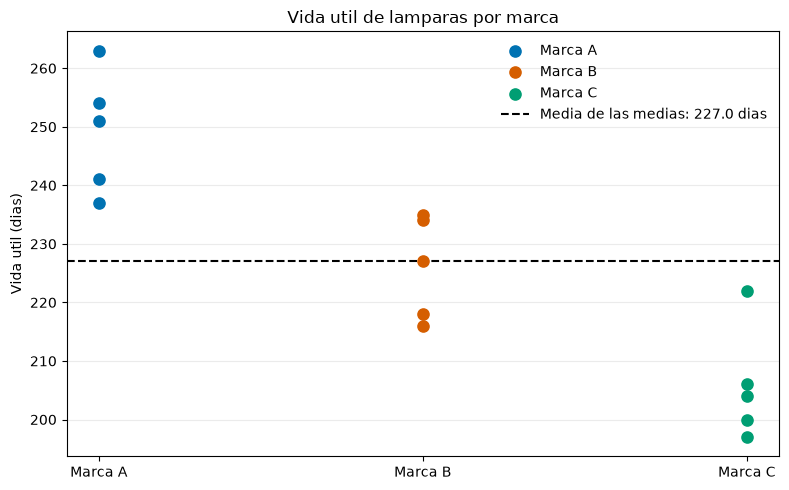

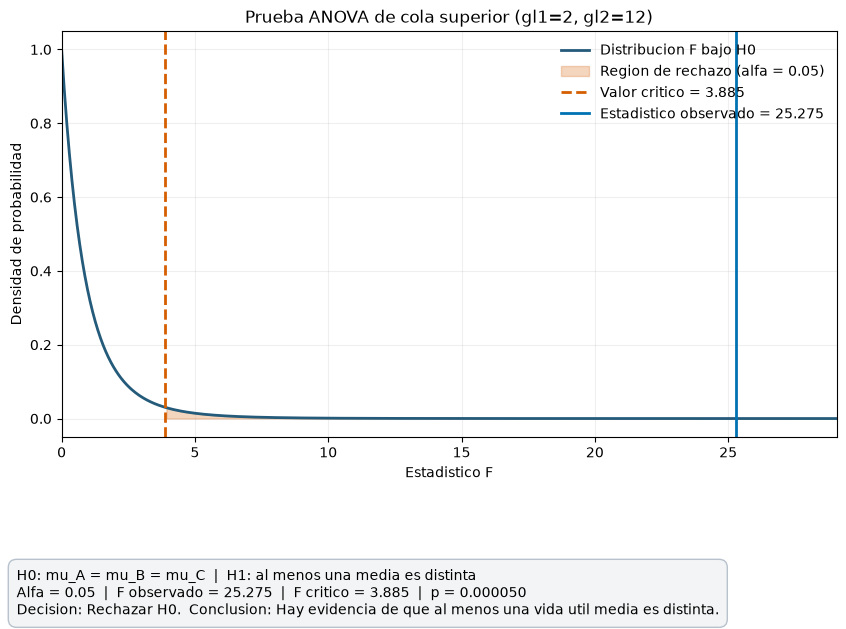

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos: vida util (dias) de cinco lamparas por marca.
marcas = {
    "Marca A": np.array([254, 263, 241, 237, 251]),
    "Marca B": np.array([234, 218, 235, 227, 216]),
    "Marca C": np.array([200, 222, 197, 206, 204]),
}

# 1. Resumen descriptivo de cada grupo.
print("Resumen descriptivo (dias)")
print(f"{'Marca':<12}{'n':>4}{'Media':>12}{'Desv. est.':>14}")
for nombre, valores in marcas.items():
    print(f"{nombre:<12}{len(valores):>4}{np.mean(valores):>12.2f}{np.std(valores, ddof=1):>14.2f}")

# 2. Hipotesis: H0: las tres medias son iguales; H1: al menos una difiere.
# 3. Descomposicion de la variabilidad para construir la tabla ANOVA.
observaciones = np.concatenate(list(marcas.values()))
media_general = np.mean(observaciones)
k = len(marcas)
n_total = len(observaciones)

suma_cuadrados_entre = sum(
    len(valores) * (np.mean(valores) - media_general) ** 2
    for valores in marcas.values()
)
suma_cuadrados_dentro = sum(
    np.sum((valores - np.mean(valores)) ** 2)
    for valores in marcas.values()
)
gl_entre = k - 1
gl_dentro = n_total - k
cuadrado_medio_entre = suma_cuadrados_entre / gl_entre
cuadrado_medio_dentro = suma_cuadrados_dentro / gl_dentro
estadistico_f = cuadrado_medio_entre / cuadrado_medio_dentro
valor_p = stats.f.sf(estadistico_f, gl_entre, gl_dentro)
f_critico = stats.f.ppf(0.95, gl_entre, gl_dentro)

print("\nTabla ANOVA de un factor")
print(f"{'Fuente':<18}{'SC':>12}{'gl':>8}{'CM':>12}{'F':>10}{'p-valor':>12}")
print(f"{'Entre marcas':<18}{suma_cuadrados_entre:>12.2f}{gl_entre:>8}{cuadrado_medio_entre:>12.2f}{estadistico_f:>10.2f}{valor_p:>12.6f}")
print(f"{'Dentro (error)':<18}{suma_cuadrados_dentro:>12.2f}{gl_dentro:>8}{cuadrado_medio_dentro:>12.2f}")
print(f"{'Total':<18}{suma_cuadrados_entre + suma_cuadrados_dentro:>12.2f}{n_total - 1:>8}")
print(f"\nNivel de significacion: 0.05 | F critico: {f_critico:.3f}")

# Verificacion independiente del estadistico F con SciPy.
f_scipy, p_scipy = stats.f_oneway(*marcas.values())
assert np.isclose(estadistico_f, f_scipy) and np.isclose(valor_p, p_scipy)

if valor_p < 0.05:
    print("Decision: se rechaza H0. Hay evidencia de que no todas las vidas medias son iguales.")
else:
    print("Decision: no se rechaza H0. No hay evidencia suficiente de diferencias entre las medias.")

# 4. Grafico descriptivo: puntos por marca y media de las medias.
fig, ax = plt.subplots(figsize=(8, 5))
posiciones = np.arange(1, k + 1)
colores = ["#0072B2", "#D55E00", "#009E73"]
media_de_medias = np.mean([np.mean(valores) for valores in marcas.values()])

for posicion, (nombre, valores), color in zip(posiciones, marcas.items(), colores):
    ax.scatter(
        np.full(len(valores), posicion),
        valores,
        color=color,
        s=65,
        label=nombre,
        zorder=3,
    )

ax.axhline(
    media_de_medias,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Media de las medias: {media_de_medias:.1f} dias",
)
ax.set_xticks(posiciones, list(marcas.keys()))
ax.set_ylabel("Vida util (dias)")
ax.set_title("Vida util de lamparas por marca")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

x_max = max(estadistico_f, f_critico) * 1.15
valores_f = np.linspace(0, x_max, 600)
densidad_f = stats.f.pdf(valores_f, gl_entre, gl_dentro)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(valores_f, densidad_f, color="#245A7A", linewidth=2, label="Distribucion F bajo H0")
ax.fill_between(
    valores_f,
    densidad_f,
    where=valores_f >= f_critico,
    color="#D55E00",
    alpha=0.25,
    label="Region de rechazo (alfa = 0.05)",
)
ax.axvline(
    f_critico,
    color="#D55E00",
    linestyle="--",
    linewidth=2,
    label=f"Valor critico = {f_critico:.3f}",
)
ax.axvline(
    estadistico_f,
    color="#0072B2",
    linestyle="-",
    linewidth=2,
    label=f"Estadistico observado = {estadistico_f:.3f}",
)
ax.set_xlim(0, x_max)
ax.set_xlabel("Estadistico F")
ax.set_ylabel("Densidad de probabilidad")
ax.set_title(f"Prueba ANOVA de cola superior (gl1={gl_entre}, gl2={gl_dentro})")
ax.grid(alpha=0.2)
ax.legend(loc="upper right", frameon=False)

if valor_p < 0.05:
    decision_grafica = "Rechazar H0"
    conclusion_grafica = "Hay evidencia de que al menos una vida util media es distinta."
else:
    decision_grafica = "No rechazar H0"
    conclusion_grafica = "No hay evidencia suficiente para afirmar que las medias difieren."

texto_resultado = (
    "H0: mu_A = mu_B = mu_C  |  H1: al menos una media es distinta\n"
    f"Alfa = 0.05  |  F observado = {estadistico_f:.3f}  |  F critico = {f_critico:.3f}  |  p = {valor_p:.6f}\n"
    f"Decision: {decision_grafica}.  Conclusion: {conclusion_grafica}"
)
fig.subplots_adjust(bottom=0.30)
fig.text(
    0.08,
    0.04,
    texto_resultado,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.6", "facecolor": "#F2F4F5", "edgecolor": "#B8C2CC"},
)
plt.show()

In [5]:
from itertools import combinations

alpha_tukey = 0.05
comparaciones_tukey = []
q_critico = stats.studentized_range.ppf(1 - alpha_tukey, k, gl_dentro)

for (marca_i, datos_i), (marca_j, datos_j) in combinations(marcas.items(), 2):
    n_i = len(datos_i)
    n_j = len(datos_j)
    diferencia_medias = np.mean(datos_i) - np.mean(datos_j)
    error_estandar = np.sqrt(cuadrado_medio_dentro / 2 * (1 / n_i + 1 / n_j))
    q_observado = abs(diferencia_medias) / error_estandar
    p_ajustado = stats.studentized_range.sf(q_observado, k, gl_dentro)
    margen_error = q_critico * error_estandar
    limite_inferior = diferencia_medias - margen_error
    limite_superior = diferencia_medias + margen_error
    significativa = p_ajustado < alpha_tukey

    comparaciones_tukey.append({
        "comparacion": f"{marca_i} - {marca_j}",
        "diferencia": diferencia_medias,
        "q": q_observado,
        "p_ajustado": p_ajustado,
        "ic_inferior": limite_inferior,
        "ic_superior": limite_superior,
        "significativa": significativa,
    })

print("Tukey-Kramer: comparaciones por pares")
print(f"Alfa = {alpha_tukey:.2f} | q critico = {q_critico:.3f} | gl error = {gl_dentro}")
print(f"{'Comparacion':<20}{'Dif. medias':>14}{'q observado':>14}{'p ajustado':>14}{'IC 95%':>25}{'Decision':>18}")
for resultado in comparaciones_tukey:
    intervalo = f"[{resultado['ic_inferior']:.2f}, {resultado['ic_superior']:.2f}]"
    decision = "Significativa" if resultado["significativa"] else "No significativa"
    print(
        f"{resultado['comparacion']:<20}"
        f"{resultado['diferencia']:>14.2f}"
        f"{resultado['q']:>14.3f}"
        f"{resultado['p_ajustado']:>14.6f}"
        f"{intervalo:>25}"
        f"{decision:>18}"
    )

comparaciones_significativas = [
    resultado for resultado in comparaciones_tukey if resultado["significativa"]
]
print("\nConclusion de Tukey-Kramer:")
if comparaciones_significativas:
    for resultado in comparaciones_significativas:
        marca_i, marca_j = resultado["comparacion"].split(" - ")
        marca_mayor, marca_menor = (
            (marca_i, marca_j) if resultado["diferencia"] > 0 else (marca_j, marca_i)
        )
        print(
            f"- {marca_mayor} tiene una vida util media significativamente mayor que "
            f"{marca_menor} (diferencia = {abs(resultado['diferencia']):.2f} dias, "
            f"p ajustado = {resultado['p_ajustado']:.6f})."
        )
else:
    print("No se detectaron diferencias significativas entre pares de marcas.")

Tukey-Kramer: comparaciones por pares
Alfa = 0.05 | q critico = 3.773 | gl error = 12
Comparacion            Dif. medias   q observado    p ajustado                   IC 95%          Decision
Marca A - Marca B            23.20         5.371      0.006634            [6.90, 39.50]     Significativa
Marca A - Marca C            43.40        10.047      0.000034           [27.10, 59.70]     Significativa
Marca B - Marca C            20.20         4.676      0.015990            [3.90, 36.50]     Significativa

Conclusion de Tukey-Kramer:
- Marca A tiene una vida util media significativamente mayor que Marca B (diferencia = 23.20 dias, p ajustado = 0.006634).
- Marca A tiene una vida util media significativamente mayor que Marca C (diferencia = 43.40 dias, p ajustado = 0.000034).
- Marca B tiene una vida util media significativamente mayor que Marca C (diferencia = 20.20 dias, p ajustado = 0.015990).


## Resultado e interpretacion del ANOVA

Las medias muestrales son 249.2 días para A, 226.0 días para B y 205.8 días para C. La tabla ANOVA da $F(2,12)=25.28$ y $p=0.000050$. Como $p<0.05$ (y $F=25.28>F_{crítico}=3.885$), se **rechaza $H_0$**. Existe evidencia de que al menos una marca tiene una vida útil media distinta, pero el ANOVA global no especifica cuáles marcas difieren.

## Procedimiento post hoc de Tukey-Kramer

Una vez rechazado $H_0$, se comparan las marcas de dos en dos. Tukey-Kramer ajusta las comparaciones para controlar el error familiar (la probabilidad de falsos positivos al considerar todos los pares). Utiliza el cuadrado medio del error y los grados de libertad residuales del ANOVA. Para cada par $i,j$ calcula:

$$
q_{ij}=\frac{|\bar{x}_i-\bar{x}_j|}{\sqrt{\frac{CM_{error}}{2}\left(\frac{1}{n_i}+\frac{1}{n_j}\right)}}
$$

Se compara $q_{ij}$ con el valor crítico de la distribución del rango studentizado, o equivalentemente se compara el valor p ajustado con $\alpha=0.05$. El código también calcula el intervalo de confianza simultáneo del 95 % para cada diferencia; si el intervalo no contiene cero, la diferencia es significativa. Como los tamaños de muestra son iguales, Tukey-Kramer coincide aquí con el procedimiento de Tukey HSD.

Para estos datos, $q_{crítico}=3.773$ (3 marcas y 12 grados de libertad del error):

| Comparación | Diferencia de medias (días) | p ajustado | IC simultáneo del 95 % | Decisión |
|---|---:|---:|---:|---|
| A - B | 23.20 | 0.006634 | [6.90, 39.50] | Significativa |
| A - C | 43.40 | 0.000034 | [27.10, 59.70] | Significativa |
| B - C | 20.20 | 0.015990 | [3.90, 36.50] | Significativa |

### Conclusión

A un nivel familiar de significación del 5 %, las tres diferencias por pares son estadísticamente significativas: **Marca A tiene mayor vida útil media que B y C, y Marca B tiene mayor vida útil media que C**. Los tres intervalos simultáneos excluyen cero y todos los valores p ajustados son menores que 0.05. El orden de las medias en esta muestra es A (249.2 días) > B (226.0 días) > C (205.8 días).